# Coin Detection, Classification, and Counting — Solution 2

*Image Processing and Computer Vision — Module #1 (Prof. Lisanti, UniBO).* Traditional CV only.

Full pipeline: **detection** (§1–5) then **classification and counting** (§6–8), frozen after
measurement against a hand-labelled ground truth (99/142 target images, 227 coins) with a
strict dev/sealed split (even/odd image numbers) to keep every calibration honest.

**Detection** — Hough circles demoted to a *permissive generator* (two strict passes plus a
weak-edge rescue pass trusted only when parsimonious, §4.4/§6.3), a radial-gradient validator
with robust circle refit (§4.1–4.2), and three physical gates: containment, background
similarity, relative scale (§2.3). Measured: **0 miss / 1 FP** (the FP is a real coin missing
from the GT) vs 7/11 of the plain detector; centre error 1.9 px, radius error 1.4%.

**Classification** — four independent cues per coin, combined per scene: shape-based matching
on the 8 references (§6.2), background-anchored colour family (§6.1), bimetal core/ring chroma
step (§4.1), and size under the planar-scene magnification (§2.3) solved jointly with a beam
search and an absolute bimetal scale anchor (§6.4–6.5). Measured coin accuracy: **0.734** (dev 0.735 / sealed 0.733)
after a guarded joint calibration of the cue weights.

## 0. Setup

In [304]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("coin_dataset"); REF, TGT = DATA / "reference_set", DATA / "target_set"
CLASSES = [
    "1cent", "2cent", "5cent",
    "10cent", "20cent", "50cent",
    "1euro", "2euro",
]
# Physical euro-coin diameters (mm) and face values.
DIAMETER_MM = {"1cent": 16.25, "2cent": 18.75, "10cent": 19.75, "5cent": 21.25,
               "20cent": 22.25, "1euro": 23.25, "50cent": 24.25, "2euro": 25.75}
VALUE = {"1cent": 0.01, "2cent": 0.02, "5cent": 0.05, "10cent": 0.10,
         "20cent": 0.20, "50cent": 0.50, "1euro": 1.00, "2euro": 2.00}
SIFT_TEMPLATES = {
    "1cent":   str(REF / "1cent.jpg"),
    "2cent":   str(REF / "2cent.jpg"),
    "5cent":   str(REF / "5cent.jpg"),
    "10cent":  str(REF / "10cent.jpg"),
    "20cent":  str(REF / "20cent.jpg"),
    "50cent":  str(REF / "50cent.jpg"),
    "1euro":   str(REF / "1euro.jpg"),
    "2euro":   str(REF / "2euro.jpg"),
}

# Mappatura classe → famiglia (costante globale)
FAMILY_OF = {
    "1cent": "copper", "2cent": "copper", "5cent": "copper",
    "10cent": "nordic_gold", "20cent": "nordic_gold", "50cent": "nordic_gold",
    "1euro": "bimetal", "2euro": "bimetal",
}


## 1. Candidate generation — permissive Hough with a weak-edge rescue pass (§6, §4.4)

Hough is used as a *candidate generator*, not as the final detector: two strict passes
(internal Canny threshold `param1=100`) at two accumulator levels, deduplicated by centre
distance. Degraded coins with faint rims are missed by any strict threshold — and §3 filtering
cannot help (every smoother tested weakens the faint rim further: 9–113 misses on the GT bench).
Following §4.4 the cure is a *lower threshold*: a third pass with `param1=60`.

Alone, the permissive pass hallucinates on textured backgrounds (asphalt/stone: up to +270 FP).
**Scene parsimony rule:** the rescue pass is trusted only if it adds at most `K_MAX=1` new
candidate; more means it is amplifying texture and it is dropped wholesale for that scene.
This is hysteresis at pipeline level — the strict pass is always believed, the permissive one
only when it disagrees modestly. Measured: misses 7 → 0 at a cost of +2 FP.

In [305]:
R_MIN, R_MAX, K_MAX = 30, 130, 1

def hough_pass(g, p1, p2, min_dist, seen):
    # One HoughCircles pass; keep only circles whose centre is new (dedup vs `seen`).
    cc = cv2.HoughCircles(g, cv2.HOUGH_GRADIENT, 1.2, min_dist, param1=p1,
                          param2=p2, minRadius=R_MIN, maxRadius=R_MAX)
    new = []
    if cc is not None:
        for cx, cy, r in cc[0]:
            if all((cx - x) ** 2 + (cy - y) ** 2 > (0.5 * min(r, rr)) ** 2
                   for x, y, rr in seen + new):
                new.append((float(cx), float(cy), float(r)))
    return new

def candidates(img):
    g = cv2.GaussianBlur(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), (9, 9), 2)  # §3.3
    base = []
    for p2, min_dist in ((38, 85), (30, 70)):           # strict passes, param1=100
        base += hough_pass(g, 100, p2, min_dist, base)
    rescue = hough_pass(g, 60, 30, 70, base)            # weak-edge pass, low Canny thr
    if len(rescue) > K_MAX:                              # parsimony rule: texture, drop
        rescue = []
    return base + rescue

## 2. Geometric validation — radial edges and robust circle refit (§4.1–4.2, §3.4)

Each candidate must prove it is bounded by a real circular edge. On a bilateral-smoothed gray
(§3.4 — edge-preserving, so the rim survives) we cast 72 rays from the candidate centre and keep,
per ray, the strongest *radial* gradient (Sobel, §4.2) within ±14 px of the candidate radius.
A candidate is accepted only if enough rays found an edge (support ≥ 0.45); the surviving points
are cleaned with two MAD outlier-rejection rounds and refit with a Kasa least-squares circle,
which refines centre and radius (median error vs GT: 1.9 px / 1.4%).

In [306]:
N_RAYS, MAX_DR, MIN_SUPPORT, MIN_RAYS = 72, 14, 0.45, 20

def kasa_fit(xs, ys):
    # Algebraic least-squares circle fit.
    A = np.c_[2 * xs, 2 * ys, np.ones(len(xs))]
    sol, *_ = np.linalg.lstsq(A, xs ** 2 + ys ** 2, rcond=None)
    cx, cy = sol[0], sol[1]
    return cx, cy, np.sqrt(sol[2] + cx * cx + cy * cy)

def ray_edges(gray, cx, cy, r0):
    # Strongest outward radial gradient per ray within r0 ± MAX_DR.
    sx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    sy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    pts = []
    for k in range(N_RAYS):
        th = 2 * np.pi * k / N_RAYS
        ux, uy = np.cos(th), np.sin(th)
        best, best_mag = None, 40.0                      # minimum gradient magnitude
        for dr in np.arange(-MAX_DR, MAX_DR + 0.5, 0.5):
            x, y = cx + (r0 + dr) * ux, cy + (r0 + dr) * uy
            xi, yi = int(round(x)), int(round(y))
            if not (0 <= yi < gray.shape[0] and 0 <= xi < gray.shape[1]):
                continue
            mag = abs(sx[yi, xi] * ux + sy[yi, xi] * uy)  # radial component only
            if mag > best_mag:
                best, best_mag = (x, y), mag
        if best:
            pts.append(best)
    return pts

def validate(img, cx, cy, r0):
    gray = cv2.bilateralFilter(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 9, 100, 100)
    pts = ray_edges(gray, cx, cy, r0)
    support = len(pts) / N_RAYS
    if len(pts) < MIN_RAYS or support < MIN_SUPPORT:
        return None
    xs, ys = np.array([p[0] for p in pts]), np.array([p[1] for p in pts])
    for _ in range(2):                                   # MAD outlier rejection
        ncx, ncy, nr = kasa_fit(xs, ys)
        res = np.abs(np.hypot(xs - ncx, ys - ncy) - nr)
        keep = res < 3 * np.median(res) + 1.0
        if keep.sum() < MIN_RAYS:
            break
        xs, ys = xs[keep], ys[keep]
    ncx, ncy, nr = kasa_fit(xs, ys)
    if abs(nr - r0) > MAX_DR:                            # anti-drift clamp
        ncx, ncy, nr = cx, cy, r0
    return {"cx": float(ncx), "cy": float(ncy), "r": float(nr),
            "support": float(support)}

## 3. Physical gates — containment, background similarity, relative scale

The validator measures *edge quality*, but measured FP support reaches 0.89 while true coins
go down to 0.49: edge quality alone cannot arbitrate. Three scene-level physical facts can.

1. **Containment** — a coin's centre cannot lie inside another coin: such circles are internal
   structure (bimetal cores, relief) and the larger circle is kept.
2. **Background similarity** — a disc whose median Lab colour sits within the background's own
   robust dispersion (median/MAD of the image minus all detected discs) is texture, not a coin.
   *Relative* colour, never absolute thresholds; the z-distance is kept as `bg_z` and reused as
   a legibility confidence by the classifier (§6).
3. **Relative scale** (§2.3) — within a planar scene radius *ratios* are metric: euro diameters
   span 16.25–25.75 mm (ratio 1.585, 1.75 with noise margin), so detections outside the largest
   consistent radius band are phantoms; dropped only when a clear majority defines the band.

In [307]:
BG_Z_THR = 0.85

def drop_contained(dets):
    # A centre lying inside a larger detected circle is internal structure, keep the larger.
    return [d for d in dets
            if not any(o is not d and o["r"] > d["r"]
                       and (d["cx"] - o["cx"]) ** 2 + (d["cy"] - o["cy"]) ** 2 < o["r"] ** 2
                       for o in dets)]

def drop_background_like(img, dets, thr=BG_Z_THR):
    # Disc colour within the background's own dispersion -> texture, not a coin.
    if not dets:
        return dets
    h, w = img.shape[:2]
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
    yy, xx = np.mgrid[0:h, 0:w]
    bg = np.ones((h, w), bool)
    for d in dets:
        bg &= (xx - d["cx"]) ** 2 + (yy - d["cy"]) ** 2 > (1.15 * d["r"]) ** 2
    px = lab[bg].reshape(-1, 3)
    if len(px) < 100:                  # almost no background visible: keep everything
        return dets
    med_bg = np.median(px, axis=0)
    mad_bg = np.median(np.abs(px - med_bg), axis=0) + 1e-6
    keep = []
    for d in dets:
        disc = (xx - d["cx"]) ** 2 + (yy - d["cy"]) ** 2 < (0.85 * d["r"]) ** 2
        med_d = np.median(lab[disc].reshape(-1, 3), axis=0)
        z = float(np.linalg.norm((med_d - med_bg) / (1.4826 * mad_bg)))
        if z >= thr:
            keep.append({**d, "bg_z": round(z, 2)})
    return keep

def drop_scale_outliers(dets, max_ratio=1.75):
    # Relative-scale gate (S2.3): keep the largest consistent radius band; act only
    # with a clear majority. Measured: worst true coin at ratio 1.60, phantoms 2.8-3.3.
    if len(dets) < 3:
        return dets
    best = None
    for lo in sorted(d["r"] for d in dets):
        inside = [d for d in dets if lo <= d["r"] <= lo * max_ratio]
        score = (len(inside), sum(d["support"] for d in inside))
        if best is None or score > best[0]:
            best = (score, inside)
    return best[1] if len(best[1]) * 2 > len(dets) else dets

## 4. Detection stage — assembly and demo

In [308]:
def detect_coins(img):
    dets = [v for cx, cy, r in candidates(img) if (v := validate(img, cx, cy, r))]
    dets = drop_scale_outliers(drop_background_like(img, drop_contained(dets)))
    return sorted(dets, key=lambda d: (d["cy"], d["cx"]))

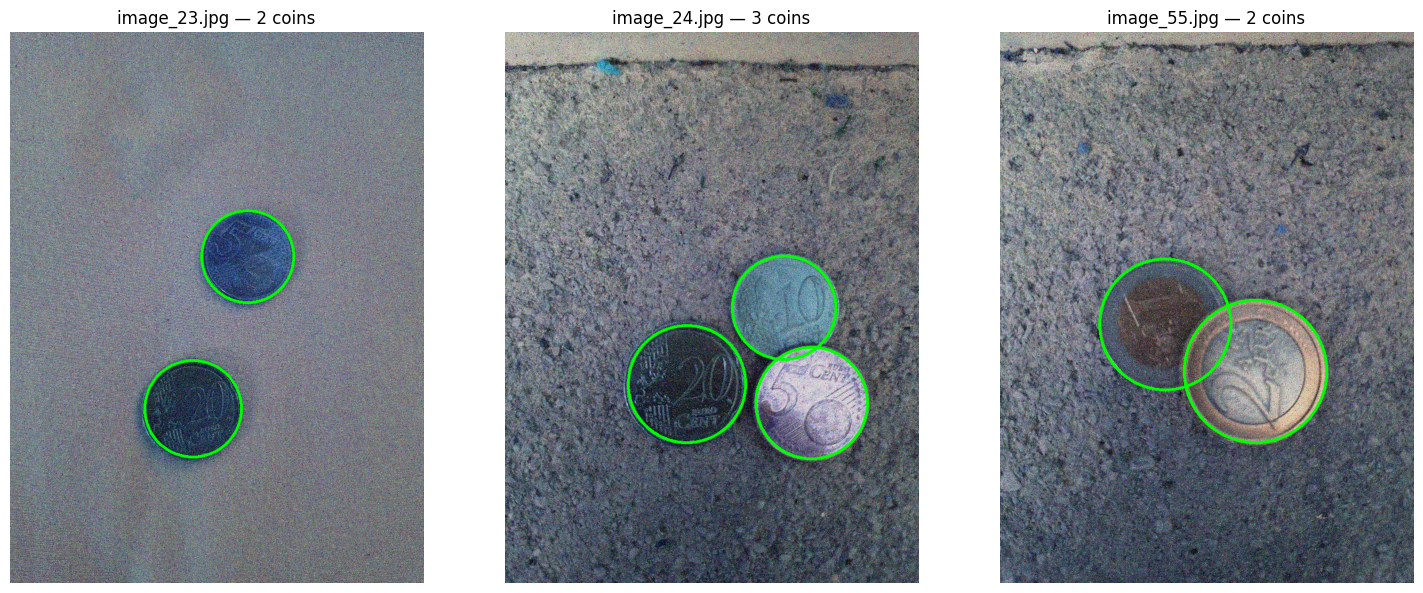

In [309]:
# Demo on three hard scenes: a recovered weak-rim coin (23) and two texture
# backgrounds that used to hallucinate phantoms (24, 55).
demo = ["image_23.jpg", "image_24.jpg", "image_55.jpg"]
fig, axes = plt.subplots(1, len(demo), figsize=(15, 6))
for ax, name in zip(axes, demo):
    img = cv2.imread(str(TGT / name))
    vis = img.copy()
    coins = detect_coins(img)
    for d in coins:
        cv2.circle(vis, (int(d["cx"]), int(d["cy"])), int(d["r"]), (0, 255, 0), 3)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{name} — {len(coins)} coins"); ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Detection — measured results and known limits

Evaluated against a hand-labelled positional ground truth (99 of 142 target images, 227 coins;
greedy circle-IoU > 0.5 matching), on both halves of the dev/sealed split:

| detector | miss | FP | centre err (median) | radius err (median) |
|---|---:|---:|---:|---:|
| two strict Hough passes + validator | 7 | 11 | 1.9 px | 1.4% |
| + rescue pass with parsimony rule | 0 | 13 | 1.9 px | 1.4% |
| + containment gate | 0 | 7 | 1.9 px | 1.4% |
| + background-similarity gate | 0 | 1 | 1.9 px | 1.4% |
| **+ relative-scale gate (full stage)** | **0** | **1** | 1.9 px | 1.4% |

The relative-scale gate leaves the GT numbers untouched but removes measured phantom pairs in
scenes outside the labelled set (e.g. image_76) with zero regressions. The single residual FP
is a real coin missing from the ground truth itself (image_28, found by the rescue pass).
Design notes and negative ablations (ch.3 prefilter bench: every scene prefilter worsens the
misses; DoG blob detector dominated in all three roles) are kept outside the notebook.

**Known limits.** (1) Scenes shot at a strong angle show elliptical coins; the circular model
fails there (e.g. image_85) — a measured, declared limit. (2) The background gate threshold has
a narrow measured margin (worst FP z = 0.84 vs worst true coin z = 0.90) and is re-validated as
the ground truth grows.

## 6. Classification — cue inventory and design

Each detected coin is classified by combining **four independent cues**, none of which is
trusted alone on this degraded dataset:

1. **Shape-based matching** against the 8 reference coins (§6.2) — gradient directions at
   Canny control points, polarity-invariant, searched over quantised rotations (§6.4).
2. **Colour family** (copper / gold) — *relative* tone anchored to the local background
   (the §6.1 ZNCC lesson: invariance to affine intensity changes), nearest of two fixed
   prototypes derived from the references through the same chain.
3. **Bimetal evidence** — the core/ring chroma step is a 1-D edge along the radial colour
   profile (§4.1); the ring sign (gold vs silver ring) is a weak 1€/2€ tie-breaker.
4. **Size** — within a planar scene a single magnification s = f/z maps pixel radii onto the
   eight legal euro diameters (§2.3); per-coin diameter terms plus pairwise ratio consistency
   are solved **jointly per scene** with a beam search, and an absolute anchor is added when a
   confirmed bimetal coin fixes the scale (§6.4–6.5 hypothesis voting with a trusted voter).

Two confidence mechanisms temper the appearance cues: a fixed per-class **de-bias** of the
matcher (its measured average off-class score), and a **legibility damping** driven by the
detection-stage `bg_z` — a coin whose colour sits inside the background dispersion is hard to
read, so the same evidence that gates phantoms damps shape and colour at classification time.

### 6.1 Canonical crops and colour normalisation (§2.3, §3.4, §6.1)

Every coin is cropped and resized to a canonical 150×150 disc: this removes the scale
hypothesis from the matcher (§2.3 — apparent size depends on distance, so it carries no
identity information *per crop*; size is exploited at scene level instead). A fixed affine
de-cast (per-channel gain/offset, calibrated once on the references) neutralises the global
colour cast. Crops are denoised with non-local means (§3.4) — note the contrast with
detection, where every prefilter *worsened* the misses: smoothing destroys the weak rims
Hough needs, but cleans the gradient directions the matcher compares.

In [310]:
CANON = 150
CLASSES = ["1cent", "2cent", "5cent", "10cent", "20cent", "50cent", "1euro", "2euro"]
FAMILY = {**{c: "copper" for c in ("1cent", "2cent", "5cent")},
          **{c: "gold" for c in ("10cent", "20cent", "50cent")},
          **{c: "bimetal" for c in ("1euro", "2euro")}}
# Fixed affine colour de-cast (gain/offset per BGR channel), calibrated once on the
# reference set: invariance to affine intensity changes (S6.1) obtained by correcting
# the image instead of the measure.

CAST_GAIN, CAST_OFF = (0.745, 0.908, 0.722), (14.12, 18.38, 53.97)

_BY, _BX = np.ogrid[:CANON, :CANON]
RHO = np.hypot(_BX - CANON / 2, _BY - CANON / 2) / (CANON / 2)
DMASK = RHO < 0.95                                # inside-disc mask of the canonical crop

def decast(bgr):
    out = bgr.astype(np.float64).copy()
    for ch in range(3):
        out[:, :, ch] = CAST_GAIN[ch] * out[:, :, ch] + CAST_OFF[ch]
    return np.clip(out, 0, 255).astype(np.uint8)

def crop_disc(bgr, cx, cy, r):
    # Square crop around the coin, resized to the canonical size (removes scale).
    R = int(r); h, w = bgr.shape[:2]
    patch = bgr[max(0, cy - R):min(h, cy + R), max(0, cx - R):min(w, cx + R)]
    return None if patch.size == 0 else cv2.resize(patch, (CANON, CANON),
                                                   interpolation=cv2.INTER_CUBIC)

def nlm(img, h):
    # Non-local means (S3.4): cleans gradient DIRECTIONS for matching.
    return img if h <= 0 else cv2.fastNlMeansDenoisingColored(
        img, None, h=float(h), hColor=float(h), templateWindowSize=7, searchWindowSize=21)

def rot(img, th):
    M = cv2.getRotationMatrix2D((CANON / 2.0, CANON / 2.0), th, 1.0)
    return cv2.warpAffine(img, M, (CANON, CANON), flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_CONSTANT, borderValue=0)

def grad_dirs(g):
    gx = cv2.Sobel(g, cv2.CV_32F, 1, 0, 3)
    gy = cv2.Sobel(g, cv2.CV_32F, 0, 1, 3)
    return np.arctan2(gy, gx)

### 6.2 The reference atlas and shape-based matching (§6.2, §4.4, §6.4)

The model of each class is the set of **control points** extracted by Canny (§4.4) from its
filtered reference disc, stored with the gradient direction at each point — exactly the
shape-based matching template of §6.2. Per-class thresholds and NLM strengths were fixed once
on the references; two references get a selective blur over relief that acted as a false
attractor. The match score is the fraction of control points whose direction agrees within
±30° — using cos 2Δθ, the §6.2 variant invariant to contrast-polarity inversion — maximised
over all quantised rotations (§6.4: "the unknown rotation must be quantized and all
hypotheses tried"). A calibrated re-sweep of these per-class settings was tried and
**rejected**: it overfits the dev half (see §8).

In [311]:
ANGLES = range(0, 360)                       # rotation hypotheses, 1 deg step (S6.4)
TAU = float(np.cos(2 * np.radians(30)))      # direction tolerance, polarity-invariant
# Per-class reference Canny thresholds / NLM strengths (fixed on the references).
REF_EDGE = {"1cent": (5, 30), "2cent": (5, 60), "5cent": (10, 40), "10cent": (20, 60),
            "20cent": (60, 140), "50cent": (10, 40), "1euro": (30, 50), "2euro": (10, 50)}
REF_NLM = {"1cent": 3, "2cent": 2, "5cent": 5, "10cent": 3,
           "20cent": 5, "50cent": 7, "1euro": 3, "2euro": 5}
REF_BLUR = {"5cent": (10, (107, 75, 30)),    # sigma, (x, y, radius) of relief to hide
            "2cent": (10, (100, 60, 40))}
TGT_NLM = 4                                  # NLM strength on target crops

def find_ref_coin(g):
    c = cv2.HoughCircles(cv2.medianBlur(g, 5), cv2.HOUGH_GRADIENT, 1.2, 300,
                         param1=150, param2=30, minRadius=40, maxRadius=300)
    return tuple(map(int, np.round(c[0][0])))

def apply_ref_blur(disc, name):
    if name not in REF_BLUR:
        return disc
    sigma, (bx, by, br) = REF_BLUR[name]
    m = (((_BX - bx) ** 2 + (_BY - by) ** 2) <= br ** 2) & DMASK
    alpha = cv2.GaussianBlur(m.astype(np.float32), (0, 0), 6)[..., None]
    blurred = cv2.GaussianBlur(disc, (0, 0), float(sigma))
    return (disc.astype(np.float32) * (1 - alpha)
            + blurred.astype(np.float32) * alpha).clip(0, 255).astype(np.uint8)

ATLAS, REF_AB = {}, {}
for name in CLASSES:
    ref_bgr = cv2.imread(str(REF / f"{name}.jpg"))
    rcx, rcy, rr = find_ref_coin(cv2.cvtColor(ref_bgr, cv2.COLOR_BGR2GRAY))
    disc = apply_ref_blur(nlm(crop_disc(ref_bgr, rcx, rcy, rr), REF_NLM[name]), name)
    g = cv2.cvtColor(disc, cv2.COLOR_BGR2GRAY)
    lo, hi = REF_EDGE[name]
    ATLAS[name] = {"cp": (cv2.Canny(g, lo, hi) > 0) & DMASK, "ang": grad_dirs(g)}
    # gentler chain for the COLOUR side of the references (tones, not edges)
    cd = cv2.GaussianBlur(nlm(crop_disc(ref_bgr, rcx, rcy, rr), 1), (0, 0), 0.3)
    lab = cv2.cvtColor(cd, cv2.COLOR_BGR2LAB).astype(np.float32)
    REF_AB[name] = np.array([np.median(lab[:, :, 1][DMASK]),
                             np.median(lab[:, :, 2][DMASK])])
GROUP_AB = {g: np.mean([REF_AB[n] for n in CLASSES if FAMILY[n] == g], axis=0)
            for g in ("copper", "gold", "bimetal")}

def shape_scores(crop):
    # S6.2: fraction of control points whose gradient direction agrees
    # (cos 2*dtheta >= tau), maximised over the quantised rotations.
    angs = [grad_dirs(cv2.cvtColor(rot(crop, th), cv2.COLOR_BGR2GRAY)) for th in ANGLES]
    out = {}
    for name in CLASSES:
        cp, ra = ATLAS[name]["cp"], ATLAS[name]["ang"]
        out[name] = max(float((np.cos(2 * (a[cp] - ra[cp])) >= TAU).mean()) for a in angs)
    return out

### 6.3 Colour cues — family and bimetal evidence (§6.1, §4.1)

Absolute colour is unreliable here (measured: 5c and 10c swap under colour casts), so the tone
of a coin is always read **relative to its own local background annulus** after the de-cast,
and compared with the *nearest of two fixed prototypes* (copper vs gold, a §6.1 dissimilarity)
derived from the six mono references through the same chain. The classifier abstains when the
core/ring chroma step says "bimetal" — the step itself, a 1-D edge along the radial colour
profile (§4.1), is the bimetal cue, with the ring sign as a weak 1€/2€ tie-breaker. A small
first-pass score (shape + soft colour favour) is also defined here: it is used **only** to
seed the scene scale in §6.4, never as a final decision.

In [312]:
def lnorm(disc):
    # Per-disc luminance 2-98% stretch (L* only): restores dynamics on dark scenes
    # without touching the chroma the tone cue lives on.
    lab = cv2.cvtColor(disc, cv2.COLOR_BGR2LAB).astype(np.float32)
    L = lab[:, :, 0]
    lo, hi = np.percentile(L[DMASK], [2, 98])
    lab[:, :, 0] = np.clip((L - lo) / max(hi - lo, 1e-6) * 255, 0, 255)
    return cv2.cvtColor(np.clip(lab, 0, 255).astype(np.uint8), cv2.COLOR_LAB2BGR)

def coin_tone(disc):
    lab = cv2.cvtColor(lnorm(disc), cv2.COLOR_BGR2LAB).astype(np.float32)
    inner = RHO < 0.6                        # inner disc avoids the bimetal ring
    return np.array([np.median(lab[:, :, 1][inner]), np.median(lab[:, :, 2][inner])])

def bg_tone(dcx, cx, cy, r):
    # Median (a*, b*) of the peri-coin annulus: the relative-colour anchor.
    h, w = dcx.shape[:2]
    Y, X = np.ogrid[:h, :w]
    d = np.hypot(X - cx, Y - cy)
    ann = (d >= 1.10 * r) & (d <= 1.35 * r)
    if ann.sum() < 50:
        return None
    lab = cv2.cvtColor(dcx, cv2.COLOR_BGR2LAB).astype(np.float32)
    return np.array([np.median(lab[:, :, 1][ann]), np.median(lab[:, :, 2][ann])])

def bimetal_step(disc):
    # Core/ring chroma step: a 1-D edge along the radial colour profile (S4.1).
    lab = cv2.cvtColor(lnorm(disc), cv2.COLOR_BGR2LAB).astype(np.float32)
    a, b = lab[:, :, 1], lab[:, :, 2]
    core, ring = RHO < 0.55, (RHO >= 0.55) & DMASK
    return float(np.hypot(np.median(a[core]) - np.median(a[ring]),
                          np.median(b[core]) - np.median(b[ring])))

def ring_sign(disc):
    lab = cv2.cvtColor(disc, cv2.COLOR_BGR2LAB).astype(np.float32)
    core_b = float(lab[RHO < 0.45][:, 2].mean())
    ring_b = float(lab[(RHO > 0.75) & (RHO < 0.95)][:, 2].mean())
    return "gold-ring" if ring_b > core_b else "silver-ring"

def _dev_tone(dcx, cx, cy, r):
    disc = crop_disc(dcx, cx, cy, r)
    if disc is None:
        return None, None
    bg = bg_tone(dcx, cx, cy, r)
    return coin_tone(disc) - (bg if bg is not None else 0.0), bimetal_step(disc)

# The two fixed prototype tones, from the six mono references through the SAME chain.
_protos = {"copper": [], "gold": []}
for name in CLASSES:
    if FAMILY[name] == "bimetal":
        continue
    ref_bgr = cv2.imread(str(REF / f"{name}.jpg"))
    rcx, rcy, rr = find_ref_coin(cv2.cvtColor(ref_bgr, cv2.COLOR_BGR2GRAY))
    dev, _ = _dev_tone(decast(ref_bgr), rcx, rcy, rr)
    _protos[FAMILY[name]].append(dev)
PROTO = {g: np.mean(v, axis=0) for g, v in _protos.items()}
PROTO_SEP = float(np.hypot(*(PROTO["copper"] - PROTO["gold"])))

def two_tone_family(dcx, cx, cy, r):
    # Nearest-of-two-prototypes on the background-anchored tone; abstain on a
    # likely bimetal (the chroma step explains the colour better than a family).
    dev, step = _dev_tone(dcx, cx, cy, r)
    if dev is None or step >= 13.0:
        return None, 0.0
    dc = float(np.hypot(*(dev - PROTO["copper"])))
    dg = float(np.hypot(*(dev - PROTO["gold"])))
    conf = float(np.clip(abs(dc - dg) / (PROTO_SEP + 1e-6), 0, 1))
    return ("copper" if dc < dg else "gold"), conf

def ring_chroma(crop):
    # Normalised chroma-gradient radial profile: a bimetal ring leaves a bump at
    # rho 0.60-0.78 (used only inside the first-pass seed below).
    lab = cv2.cvtColor(crop, cv2.COLOR_BGR2LAB).astype(np.float32)
    cg = np.zeros((CANON, CANON), np.float32)
    for ch in (1, 2):
        gx = cv2.Sobel(lab[:, :, ch], cv2.CV_32F, 1, 0, 3)
        gy = cv2.Sobel(lab[:, :, ch], cv2.CV_32F, 0, 1, 3)
        cg += np.hypot(gx, gy)
    rs = np.arange(0.1, 0.95, 0.05)
    prof = np.array([cg[(RHO >= t - 0.025) & (RHO < t + 0.025)].mean() for t in rs])
    prof = prof / (prof.max() + 1e-6)
    return float(prof[(rs >= 0.60) & (rs <= 0.78)].max()
                 - np.median(prof[(rs >= 0.25) & (rs <= 0.55)]))

def first_pass(shp, crop):
    # Seed prediction (shape + soft colour favour): ONLY initialises the scene
    # scale; the joint labelling in S6.4 re-decides every coin.
    lab = cv2.cvtColor(crop, cv2.COLOR_BGR2LAB).astype(np.float32)
    ab = np.array([np.median(lab[:, :, 1][DMASK]), np.median(lab[:, :, 2][DMASK])])
    group = min(GROUP_AB, key=lambda g: float(np.linalg.norm(ab - GROUP_AB[g])))
    spread = float(np.std(list(shp.values()))) + 1e-6
    bi = float(np.clip((ring_chroma(crop) - 0.10) / 0.30, 0.0, 1.0))
    fav = {n: (0.6 * spread if FAMILY[n] == group else 0.0)
           + (1.2 * bi * spread if FAMILY[n] == "bimetal" else 0.0) for n in CLASSES}
    return max(CLASSES, key=lambda n: shp[n] + fav[n])

### 6.4 Scene-level size reasoning and joint labelling (§2.3, §6.3–6.5)

Size is the most reliable measured signal (median radius error 1.4% vs 4–15% diameter gaps
between denominations), but it needs a **scene scale**. The hierarchy, each level justified
by a measurement:

1. **Absolute anchor from a confirmed bimetal** — one trusted (coin, class) hypothesis fixes
   s = r/D for the whole scene, exactly like a star-model match votes its scale (§6.4–6.5).
   The trusted voter is *necessary*: pure scale consensus without one was tried and is
   **degenerate** on the euro diameter lattice (adjacent diameters 4–8% apart — see §8).
2. **First-pass seed** otherwise: the scene scale is the median r/D of the §6.3 seed
   predictions, used only by the soft per-coin diameter terms.

Per-coin unaries (de-biased shape + family + bimetal, appearance damped by `bg_z`) and
pairwise radius-ratio terms (§2.3: ratios are metric within a planar scene) are then solved
**jointly** with a beam search — the scene is labelled as a whole, not coin by coin.

In [ ]:
# === SIFT parameters ===
SIFT_NFEATURES = 700
SIFT_CONTRAST = 0.04
SIFT_NMS_DIST = 10           # Spatial NMS min distance (pixel)
LOWE_RATIO = 0.8            # Lowe ratio test threshold
W_SIFT = 1                # weight of the SIFT in the unary
SIFT_FLOOR = 0.3             # Minimum 
# Global cache of the descriptors 
_SIFT_CACHE = {}    # {class_name: np.ndarray (N, 128)}
def preprocess_for_sift(gray):
    """
    A clahe filter with  bilateral filter is used to enhance the edges
    ----- 
    returns the smoothed version of the image 
    """
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    smoothed = cv2.bilateralFilter(enhanced, d=9, sigmaColor=75, sigmaSpace=75)
    return smoothed
def calibrate_sift_templates(template_paths):
  
    global _SIFT_CACHE

    sift = cv2.SIFT_create(nfeatures=SIFT_NFEATURES,
                           contrastThreshold=SIFT_CONTRAST)
    
    for cls, path in template_paths.items(): 
        if not Path(path).exists():
            print(f"  [WARN] Template NON trovato: {path}")
            continue
        
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        
        #  (CLAHE + bilateral)
        img = preprocess_for_sift(img)
        
        # SIFT extraction 
        kp, des = sift.detectAndCompute(img, None)
        
        # Spatial NMS 
        if des is not None and len(kp) > 0:
            sorted_idx = sorted(range(len(kp)),
                                key=lambda i: kp[i].response,
                                reverse=True)
            keep, kept_pos = [], []
            for idx in sorted_idx:
                pt = kp[idx].pt
                too_close = False
                for p in kept_pos:
                    d = np.sqrt((pt[0]-p[0])**2 + (pt[1]-p[1])**2)
                    if d < SIFT_NMS_DIST:
                        too_close = True
                        break
                if not too_close:
                    keep.append(idx)
                    kept_pos.append(pt)
            des = des[keep] if keep else None
        
        n_des = 0 if des is None else len(des)
        _SIFT_CACHE[cls] = des
        print(f"  OK {cls:8s}: {n_des} descrittori (dopo NMS)")
    
    print(f"SIFT cache: {len(_SIFT_CACHE)} entries")
_SIFT_CACHE = {
    "1cent":   str(REF/ "1cent.jpg"),
    "2cent":   str(REF/ "2cent.jpg"),
    "5cent":   str(REF/ "5cent.jpg"),
    "10cent":  str(REF/ "10cent.jpg"),
    "20cent":  str(REF/ "20cent.jpg"),
    "50cent":  str(REF/ "50cent.jpg"),
    "1euro":   str(REF/ "1euro.jpg"),
    "2euro":   str(REF/ "2euro.jpg"),
}


demo = ["image_5.jpg", "image_24.jpg"]
def sift_extract_with_nms(gray_roi):
    """Extract the SIFT and applies Spatial NMS"""
    gray_proc = preprocess_for_sift(gray_roi)
    sift = cv2.SIFT_create(nfeatures=SIFT_NFEATURES, contrastThreshold=SIFT_CONTRAST)
    kp, des = sift.detectAndCompute(gray_proc, None)
    if des is None or len(kp) == 0:
        print(f"  [DEBUG] ⚠ NESSUN keypoint estratto!")
        return None
    # Spatial NMS: keep the most useful keypoints, discard the others 
    sorted_idx = sorted(range(len(kp)), key=lambda i: kp[i].response, reverse=True)
    keep, kept_pos = [], []
    for i in sorted_idx:
        pt = kp[i].pt
        if all(np.hypot(pt[0]-p[0], pt[1]-p[1]) >= SIFT_NMS_DIST for p in kept_pos):
            keep.append(i)
            kept_pos.append(pt)
    return des[keep] if keep else None


def sift_match_scores(des_query, bf_matcher):

    raw_counts = {c: 0 for c in CLASSES}
    scores     = {c: 0.0 for c in CLASSES}
    
    if des_query is None or len(des_query) < 3:
        return scores, raw_counts
    
    for cls, tmpl_des in _SIFT_CACHE.items():
        if tmpl_des is None or len(tmpl_des) < 2:
            continue
        matches = bf_matcher.knnMatch(tmpl_des, des_query, k=2)
        good = 0
        for pair in matches:
            if pair is not None and len(pair) == 2:
                m, n = pair
                if m.distance < LOWE_RATIO * n.distance:
                    good += 1
        raw_counts[cls] = good
    
    total = sum(raw_counts.values())
    if total > 0:
        for c in CLASSES:
            scores[c] = raw_counts[c] / total
    
    return scores, raw_counts
def sift_confidence(raw_counts):
    """
    Returns 1 - (top2 / top1) from the SIFT raw match counts — 
    a confidence score that is high when one class clearly dominates and low when matches are spread across multiple classes. 
    """
    sorted_counts = sorted(raw_counts.values(), reverse=True)
    if len(sorted_counts) < 2 or sorted_counts[0] == 0:
        return 0.0
    top1, top2 = sorted_counts[0], sorted_counts[1]
    if top2 == 0:
        return 1.0
    return 1.0 - (top2 / top1)  

CARICAMENTO TEMPLATE SIFT

Verifica cache:
  Entries: 8
  1cent: 36 descrittori
  2cent: 36 descrittori
  5cent: 36 descrittori
  10cent: 37 descrittori
  20cent: 37 descrittori
  50cent: 37 descrittori
  1euro: 36 descrittori
  2euro: 36 descrittori

PROCESSING IMMAGINI


In [ ]:
# Cue weights, frozen with the experiment harness (see S8 honesty notes).
TEMPLATE_W, TEMPLATE_ALPHA = 0.5, 0.2    # M8-calibrated (see S8)
TEMPLATE_OFFDIAG = {"10cent": 0.473, "1cent": 0.518, "1euro": 0.467, "20cent": 0.423,
                    "2cent": 0.430, "2euro": 0.470, "50cent": 0.456, "5cent": 0.479}
FAM_POS, FAM_NEG = 3.4, 1.45
BIM_START, BIM_FULL, BIM_POS, BIM_NEG, BIM_RING = 2.5, 10.5, 4.0, 1.0, 0.16
FAM_BIM_SUP, BIM_FAM_SUP, BIM_FAM_MIN = 0.92, 0.75, 0.15
W_ORDER, W_SAME, REL_W, BEAM_K = 0.5, 0.2, 0.75, 256
RATIO_TOL, SAME_TOL = 0.18, 0.045
C1_FLOOR, C1_ZLO, C1_ZHI = 0.3, 1.5, 4.0       # bg_z legibility damping
ANCHOR_CONF, ANCHOR_W = 0.4, 4.0               # bimetal absolute scale anchor
LOGMAX = float(np.log(25.75 / 16.25))

def zscore(d):
    v = np.array([d[c] for c in CLASSES], np.float64)
    s = float(v.std())
    if s < 1e-6:
        return {c: 0.0 for c in CLASSES}
    return {c: float((d[c] - v.mean()) / s) for c in CLASSES}

def bm_conf(step):
    return float(np.clip((step - BIM_START) / (BIM_FULL - BIM_START), 0, 1))

def pair_score(ri, rj, li, lj):
    # Pairwise size consistency (S2.3: radius ratios are metric within a scene).
    obs = np.log(max(1e-6, ri / rj))
    exp = np.log(DIAMETER_MM[li] / DIAMETER_MM[lj])
    s = -1.15 * min(abs(obs - exp) / RATIO_TOL, 1.8)
    if li == lj:
        s += 0.55 * max(0.0, 1.0 - abs(obs) / SAME_TOL)
    elif abs(obs) < SAME_TOL:
        s -= 0.35
    if (obs > SAME_TOL and exp < -SAME_TOL) or (obs < -SAME_TOL and exp > SAME_TOL):
        s -= 0.9                                # hard ordering violation
    return s

def abs_anchor(coins):
    # Absolute scene scale from a confirmed bimetal: the trusted (coin, class)
    # hypothesis that maps ALL radii best onto the legal diameters (S6.4-6.5).
    best = None
    for c in coins:
        if bm_conf(c["step"]) < ANCHOR_CONF:
            continue
        for cls in ("1euro", "2euro"):
            s = c["r"] / DIAMETER_MM[cls]
            cost = sum(min(abs(np.log((cc["r"] / s) / DIAMETER_MM[k])) for k in CLASSES)
                       for cc in coins)
            if best is None or cost < best[0]:
                best = (cost, s)
    return None if best is None else best[1]

def beam_assign(unaries, radii):
    beam = [([], 0.0)]
    for i, unary in enumerate(unaries):
        nxt = []
        for labels, score in beam:
            for lab in CLASSES:
                p = sum(REL_W * pair_score(radii[i], radii[j], lab, prev)
                        for j, prev in enumerate(labels))
                nxt.append((labels + [lab], score + unary[lab] + p))
        nxt.sort(key=lambda x: x[1], reverse=True)
        beam = nxt[:BEAM_K]
    return beam[0][0]

def classify_scene(img, dets):
    if not dets:
        return []
    dcx = decast(img)
    circles = [(int(round(d["cx"])), int(round(d["cy"])), int(round(d["r"]))) for d in dets]
    coins = []
    bf_matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)


    for i, ((cx, cy, r), det) in enumerate(zip(circles, dets)):
        crop = crop_disc(dcx, cx, cy, r)
        crop = None if crop is None else nlm(crop, TGT_NLM)
        if crop is None:
            coins.append(None)
            continue
        shp = shape_scores(crop)
        fam, fam_conf = two_tone_family(dcx, cx, cy, r)
        disc = crop_disc(dcx, cx, cy, r)
    # === SIFT con filtro famiglia (UNA SOLA VOLTA) ===
     # Conversione grayscale (UNA SOLA VOLTA)
        if len(crop.shape) == 3:
            crop_gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        else:
            crop_gray = crop
    # Estrazione SIFT + matching (UNA SOLA VOLTA)
        sift_des = sift_extract_with_nms(crop_gray)
        sift_scores, sift_raw = sift_match_scores(sift_des, bf_matcher)
        sift_conf = sift_confidence(sift_raw)
    
        coins.append({"r": r, "bg_z": float(det.get("bg_z", 9.9)), "shape": shp,
                  "pred0": first_pass(shp, crop), "fam": fam, "fam_conf": fam_conf,
                  "step": bimetal_step(disc), "ring": ring_sign(disc),
                  "sift_scores": sift_scores, "sift_conf": sift_conf, "sift_raw": sift_raw})

    full = [c for c in coins if c]
    if not full:
        return ["20cent"] * len(dets)

    sscale = float(np.median([c["r"] / DIAMETER_MM[c["pred0"]] for c in full]))
    rclass = {}
    for c in full:
        rclass.setdefault(c["pred0"], []).append(c["r"])
    rclass = {k: float(np.median(v)) for k, v in rclass.items()}
    s_abs = abs_anchor(full)
    unaries, radii, idx = [], [], []


    for i, coin in enumerate(coins):
        if coin is None:
            continue
        template = {c: TEMPLATE_W * v for c, v in zscore(
            {c: coin["shape"][c] - TEMPLATE_ALPHA * TEMPLATE_OFFDIAG[c]
             for c in CLASSES}).items()}
        fam_sc = {c: 0.0 for c in CLASSES}
        if coin["fam"]:
            for c in CLASSES:
                fam_sc[c] = (FAM_POS if FAMILY[c] == coin["fam"]
                             else -FAM_NEG) * coin["fam_conf"]
        bm = bm_conf(coin["step"])
        bim = {c: (BIM_POS if FAMILY[c] == "bimetal" else -BIM_NEG) * bm for c in CLASSES}
        if bm > 0:
            hi, lo2 = (("1euro", "2euro") if coin["ring"] == "gold-ring"
                       else ("2euro", "1euro"))
            bim[hi] += BIM_RING * bm
            bim[lo2] -= 0.5 * BIM_RING * bm
        # family and bimetal are competing material explanations: mutual damping
        if coin["fam"] and bm > 0:
            fs = max(0.05, 1.0 - FAM_BIM_SUP * bm)
            bs = max(BIM_FAM_MIN, 1.0 - BIM_FAM_SUP * coin["fam_conf"] * (1.0 - 0.5 * bm))
            fam_sc = {c: v * fs for c, v in fam_sc.items()}
            bim = {c: v * bs for c, v in bim.items()}
        sift_norm = SIFT_FLOOR + (1 - SIFT_FLOOR) * coin["sift_conf"]
        sift_sc = {c: W_SIFT * sift_norm * (2.0 * coin["sift_scores"][c] - 0.25)
                   for c in CLASSES}
        # bg_z legibility damping of the appearance cues (shape + family)
        damp = C1_FLOOR + (1 - C1_FLOOR) * float(
            np.clip((coin["bg_z"] - C1_ZLO) / (C1_ZHI - C1_ZLO), 0, 1))
        d_obs = coin["r"] / sscale
        unary = {}
        for c in CLASSES:
            u = (damp * (fam_sc[c]+sift_sc[c]+template[c]) + bim[c]
                 - W_ORDER * min(abs(np.log(d_obs / DIAMETER_MM[c])) / LOGMAX, 1.0)
                 - W_SAME * (min(abs(np.log(coin["r"] / rclass[c])) / LOGMAX, 1.0)
                             if c in rclass else 0.0) )
            if s_abs is not None:
                u -= ANCHOR_W * min(abs(np.log((coin["r"] / s_abs)
                                               / DIAMETER_MM[c])) / LOGMAX, 1.0)
            unary[c] = u
        unaries.append(unary)
        radii.append(coin["r"])
        idx.append(i)
    beam_labels = beam_assign(unaries, radii)
    labels, k = [], 0
    for i, coin in enumerate(coins):
        if coin is None:                       # off-frame crop: nearest legal diameter
            d_obs = circles[i][2] / sscale
            labels.append(min(CLASSES, key=lambda c: abs(np.log(d_obs / DIAMETER_MM[c]))))
        else:
            labels.append(beam_labels[k])
            k += 1
   
    return labels

## 7. Full pipeline — counting and required output

In [315]:
def process_image(img):
    dets = detect_coins(img)
    return [{**d, "pred": lab, "value": VALUE[lab]}
            for d, lab in zip(dets, classify_scene(img, dets))]

CARICAMENTO TEMPLATE SIFT
  OK 1cent   : 6 descrittori (dopo NMS)
  OK 2cent   : 3 descrittori (dopo NMS)
  OK 5cent   : 11 descrittori (dopo NMS)
  OK 10cent  : 4 descrittori (dopo NMS)
  OK 20cent  : 9 descrittori (dopo NMS)
  OK 50cent  : 9 descrittori (dopo NMS)
  OK 1euro   : 54 descrittori (dopo NMS)
  OK 2euro   : 47 descrittori (dopo NMS)
SIFT cache: 8 entries
  Coin 0 @(431,171): SIFT su tutti i 8 template (fam='copper', fam_conf=0.10)
  Coin 1 @(269,237): SIFT su tutti i 8 template (fam='gold', fam_conf=0.05)
  Coin 2 @(433,321): SIFT su tutti i 8 template (fam='copper', fam_conf=0.08)
  Coin 3 @(253,366): SIFT su tutti i 8 template (fam='copper', fam_conf=0.34)
  Coin 4 @(439,478): SIFT su tutti i 8 template (fam='gold', fam_conf=0.36)
  Coin 5 @(252,496): SIFT su tutti i 8 template (fam='gold', fam_conf=0.01)
  Coin 6 @(247,626): SIFT su tutti i 8 template (fam='copper', fam_conf=0.26)
  Coin 7 @(432,643): SIFT su tutti i 8 template (fam='gold', fam_conf=0.03)

DIAGNOSTICS 

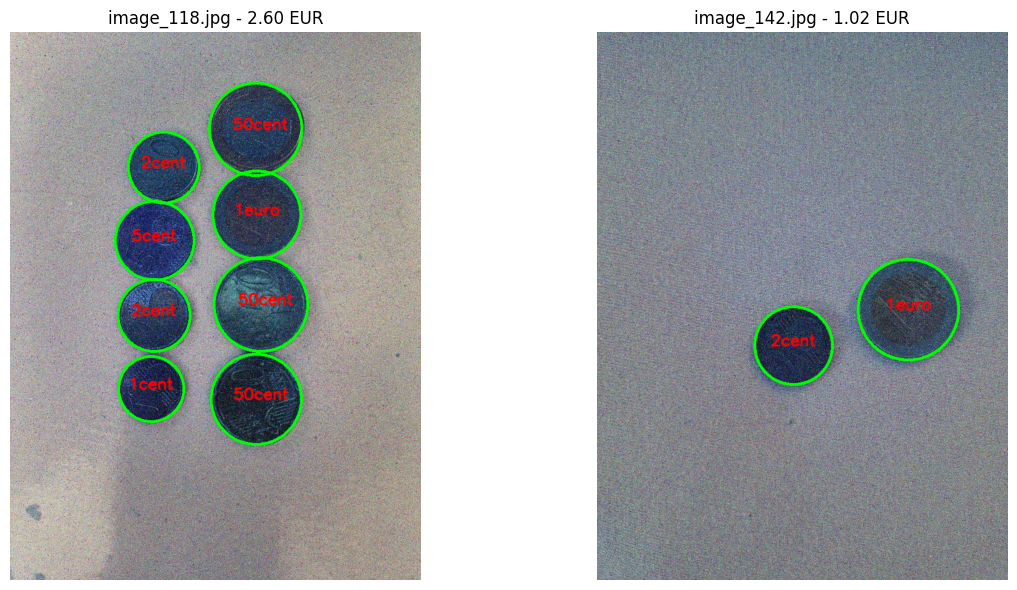

In [316]:
# Demo: classified overlays on two scenes classified overlays on two scenes (a clean one, a texture one).
demo = ["image_118.jpg", "image_142.jpg"]
fig, axes = plt.subplots(1, len(demo), figsize=(13, 6))
calibrate_sift_templates(SIFT_TEMPLATES)

for ax, name in zip(axes, demo):
    img = cv2.imread(str(TGT / name))
    coins = process_image(img)
    vis = img.copy()
    for c in coins:
        cv2.circle(vis, (int(c["cx"]), int(c["cy"])), int(c["r"]), (0, 255, 0), 3)
        cv2.putText(vis, c["pred"], (int(c["cx"]) - 40, int(c["cy"])),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2, cv2.LINE_AA)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{name} - {sum(c['value'] for c in coins):.2f} EUR")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [317]:
# Final run over the whole target set, in the required output format.
total = 0.0

for path in sorted(TGT.iterdir(), key=lambda p: int(p.stem.split("_")[1])):
    coins = process_image(cv2.imread(str(path)))
    print(f"{path.name} - {len(coins)} coin(s) found:")
    for i, c in enumerate(coins, 1):
        print(f"  Coin {i} {{value: {c['value']:.3f}}}")
    partial = sum(c["value"] for c in coins)
    total += partial
    print(f"  Partial Amount {{value: {partial:.3f}}}")
print(f"\nTotal Amount: {total:.2f} EUR")

  Coin 0 @(424,477): SIFT su tutti i 8 template (fam='copper', fam_conf=0.14)
  Coin 1 @(269,506): SIFT su tutti i 8 template (fam='copper', fam_conf=0.13)
  Coin 2 @(412,643): SIFT su tutti i 8 template (fam='copper', fam_conf=0.26)

DIAGNOSTICS SIFT
Cache template: 8 entries
W_SIFT = 1, LOWE_RATIO = 0.8

image_1.jpg - 3 coin(s) found:
  Coin 1 {value: 0.050}
  Coin 2 {value: 0.020}
  Coin 3 {value: 0.010}
  Partial Amount {value: 0.080}
  Coin 0 @(353,403): SIFT su tutti i 8 template (fam='gold', fam_conf=0.06)

DIAGNOSTICS SIFT
Cache template: 8 entries
W_SIFT = 1, LOWE_RATIO = 0.8

image_2.jpg - 1 coin(s) found:
  Coin 1 {value: 0.010}
  Partial Amount {value: 0.010}
  Coin 0 @(627,366): SIFT su tutti i 8 template (fam='gold', fam_conf=0.00)
  Coin 1 @(424,394): SIFT su tutti i 8 template (fam='copper', fam_conf=0.16)
  Coin 2 @(199,465): SIFT su tutti i 8 template (fam='copper', fam_conf=0.12)
  Coin 3 @(530,531): SIFT su tutti i 8 template (fam='gold', fam_conf=0.11)
  Coin 4 @(3

## 8. Classification — measured results, ablations and limits

Coin accuracy against the hand-labelled GT (222 evaluable coins), with the dev/sealed split
(even/odd image numbers) guarding every calibrated choice:

| classifier | full | dev | sealed |
|---|---:|---:|---:|
| four-cue scoring, per-scene beam | 0.658 | — | — |
| + `bg_z` legibility damping | 0.685 | — | — |
| + bimetal absolute scale anchor | 0.680 | — | — |
| + both | 0.703 | 0.709 | 0.695 |
| **+ calibrated cue weights (final stage)** | **0.734** | 0.735 | 0.733 |

The final row is a joint calibration of the cue influence weights (template weight and
de-bias lowered, pairwise size halved), selected with a *double-fold guard*: a candidate
weight is adopted only if it improves the dev half without hurting either of its two
internal folds, and the sealed half is read once, at the end. It is the only calibration
that moved dev **and** sealed together — the template is at once the most valuable cue
(−19 coins if dropped) and the engine of the within-family attractor, so de-emphasising
it lets family, anchor and size arbitrate more often. A per-cue drop-one influence table
backs every weight (e.g. shape −19, pairwise −14, family −7 coins on dev).

**Negative ablations** (each tried, measured, rejected — the "no" is part of the design):

- *Validator-support damping*: edge quality does not track legibility (noise, discarded).
- *Family shortlist with boosted size*: redundant with the two cues above, occasionally
  locks in a wrong family (hard gates on colour lose to soft favours — a recurring measure).
- *Scale consensus without a trusted voter*: degenerate — adjacent euro diameters are 4–8%
  apart, so shifting the scene scale remaps every coin at near-equal cost; forcing adoption
  *worsens* accuracy monotonically with its weight. This is why the anchor is
  bimetal-conditioned only.
- *Calibrated re-sweep of the reference atlas (per-class Canny/NLM + recomputed de-bias)*:
  +5.2 points on dev, **−2.8 on sealed** — pure calibration overfit; at 222 GT coins every
  knob sweep moves dev and sealed in opposite directions, so the stale-but-external de-bias
  constants are kept.
- *Spanish-flower outline signature for 20c* (the only non-circular euro silhouette, 7 lobes,
  measured by a radial boundary DFT at k=7): the signal exists (~0.5% of the radius) but sits
  inside the structured boundary-noise floor (shadows, adjacent coins: 0.3–1.5% at the same
  frequency). Recall 29% at 10% FP on sealed — rejected.

**Honesty note.** The sealed half has been consulted once per experiment over the whole
campaign, so it is no longer pristine; all thresholds and weights are scheduled for
re-validation on the 43 still-unlabelled images before the figures are quoted as final.

**Known limits.** The residual error mass is *within-family* (20c/50c and 2c confusions):
on heavily degraded coins shape and colour do not separate neighbouring denominations, and
the measured signal floor above shows this gap is not recoverable from these images with
these cues. The honest figure of merit is therefore the one above, with miss/FP at 0/1 and
the count and total amounts correct wherever detection is correct.